# CSV 파일 불러오기

# 1. student_info 분석

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

In [25]:
info = pd.read_csv("../CSV_files/studentInfo.csv")

In [26]:
info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [27]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [28]:
# 기술통계

info.describe()

,id_student,num_of_prev_attempts,studied_credits
count,3.259300e+04,32593.000000,32593.000000
mean,7.066877e+05,0.163225,79.758691
std,5.491673e+05,0.479758,41.071900
min,3.733000e+03,0.000000,30.000000
25%,5.085730e+05,0.000000,60.000000
50%,5.903100e+05,0.000000,60.000000
75%,6.444530e+05,0.000000,120.000000
max,2.716795e+06,6.000000,655.000000


In [29]:
# 결측치 확인
info.isna().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

In [30]:
# 범주형 컬럼별 고유값
cat_cols = ["gender", "region", "highest_education", "imd_band", "num_of_prev_attempts", 
            "studied_credits", "age_band", "disability", "disability" , "id_student",
            "code_presentation", "final_result"]
for c in cat_cols:
    print(f"--- {c} ---")
    print(info[c].value_counts(dropna=False), "\n")

--- gender ---
gender
M    17875
F    14718
Name: count, dtype: int64 

--- region ---
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64 

--- highest_education ---
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64 

--- imd_band ---
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64 

--- num_of_pre

## 속성별 설명

1) 핵심 식별자 및 타겟 변수

- id_student (학생 고유 ID): 다른 모든 OULAD 테이블(studentVle.csv, studentAssessment.csv 등)과 데이터를 연결(JOIN)할 때 사용하는 마스터 키(Primary Key)입니다.
- final_result (최종 결과): 과목의 최종 성취 상태입니다. Pass(통과), Distinction(우수 통과), Fail(실패), Withdrawn(수강 철회/이탈) 4가지 값을 가집니다. (우리가 예측해야 할 머신러닝의 '정답(Label)' 데이터입니다!)

2) 과목 정보
- code_module (과목 코드): 수강한 과목의 식별자 (예: AAA, BBB 등). 과목별 난이도나 특성에 따른 이탈률을 비교할 수 있습니다.
- code_presentation (개설 학기): 과목이 개설된 시기. (예: 2013J = 2013년 10월 시작, 2014B = 2014년 2월 시작). 학기별 트렌드 파악에 쓰입니다.

3) 인구통계 및 환경적 특성
- gender (성별): 학생의 성별 (M/F).
- age_band (연령대): 학생의 연령 구간 (0-35, 35-55, 55<=).
- region (거주 지역): 영국 내 거주 지역. 지역별 인프라나 특성이 학업 성취에 미치는 영향을 볼 수 있습니다.
- imd_band (빈곤지수 구간): 영국의 다중빈곤지수(Index of Multiple Deprivation). 사회경제적 수준을 나타내며, 이탈률과 매우 밀접한 연관성을 띠는 경우가 많습니다.
- disability (장애 여부): 장애 보유 여부 (Y/N). 학습 지원이 추가로 필요한 그룹의 이탈 패턴을 분석할 수 있습니다.

4) 학업 배경 및 부담 지표
- highest_education (최종 학력): 해당 과목 수강 전 학생의 최종 학력 (예: A Level, HE Qualification 등). 기초 지식수준이 완수율에 미치는 영향을 파악합니다.
- num_of_prev_attempts (과거 수강 시도 횟수): 이 과목을 과거에 몇 번이나 들으려고 했었는지 나타냅니다. 재수강생의 의지를 볼 수도 있고, 반대로 고질적인 이탈 고위험군일 수도 있습니다.
- studied_credits (수강 학점): 현재 오픈 대학교에서 수강 중인 총 학점. 학업 부담도를 나타내며, 값이 클수록 부담이 커서 이탈할 확률이 높다는 가설을 세울 수 있습니다.


# 2. Target Data : final_result

1) Distinction : 우수성적(통과)
2) Pass : 통과
3) Fail : 실패
4) Withdrawn : 중도이탈(실패)


In [31]:
# 1. 훈련 결과가 'Withdrawn'이면 "이탈"로 정의합니다.
# 조기 이탈률만 확인 하기위해'Fail'도 일단 "완수"로 분류
info["label_churn"] = info["final_result"].apply(lambda x: "이탈" if x == "Withdrawn" else "완수")

# 2. 결과가 어떻게 나뉘었는지 퍼센트로 확인
print(info["label_churn"].value_counts(normalize=True).round(3))

label_churn
완수    0.688
이탈    0.312
Name: proportion, dtype: float64


In [32]:
# 폰트 테마 설정
sns.set_theme(style="whitegrid")
# 한글 폰트 설정 (맑은 고딕) — set_theme 이후에 지정해야 덮어쓰이지 않음
plt.rc("font", family="Malgun Gothic")
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

## 전체 데이터 그래프 확인

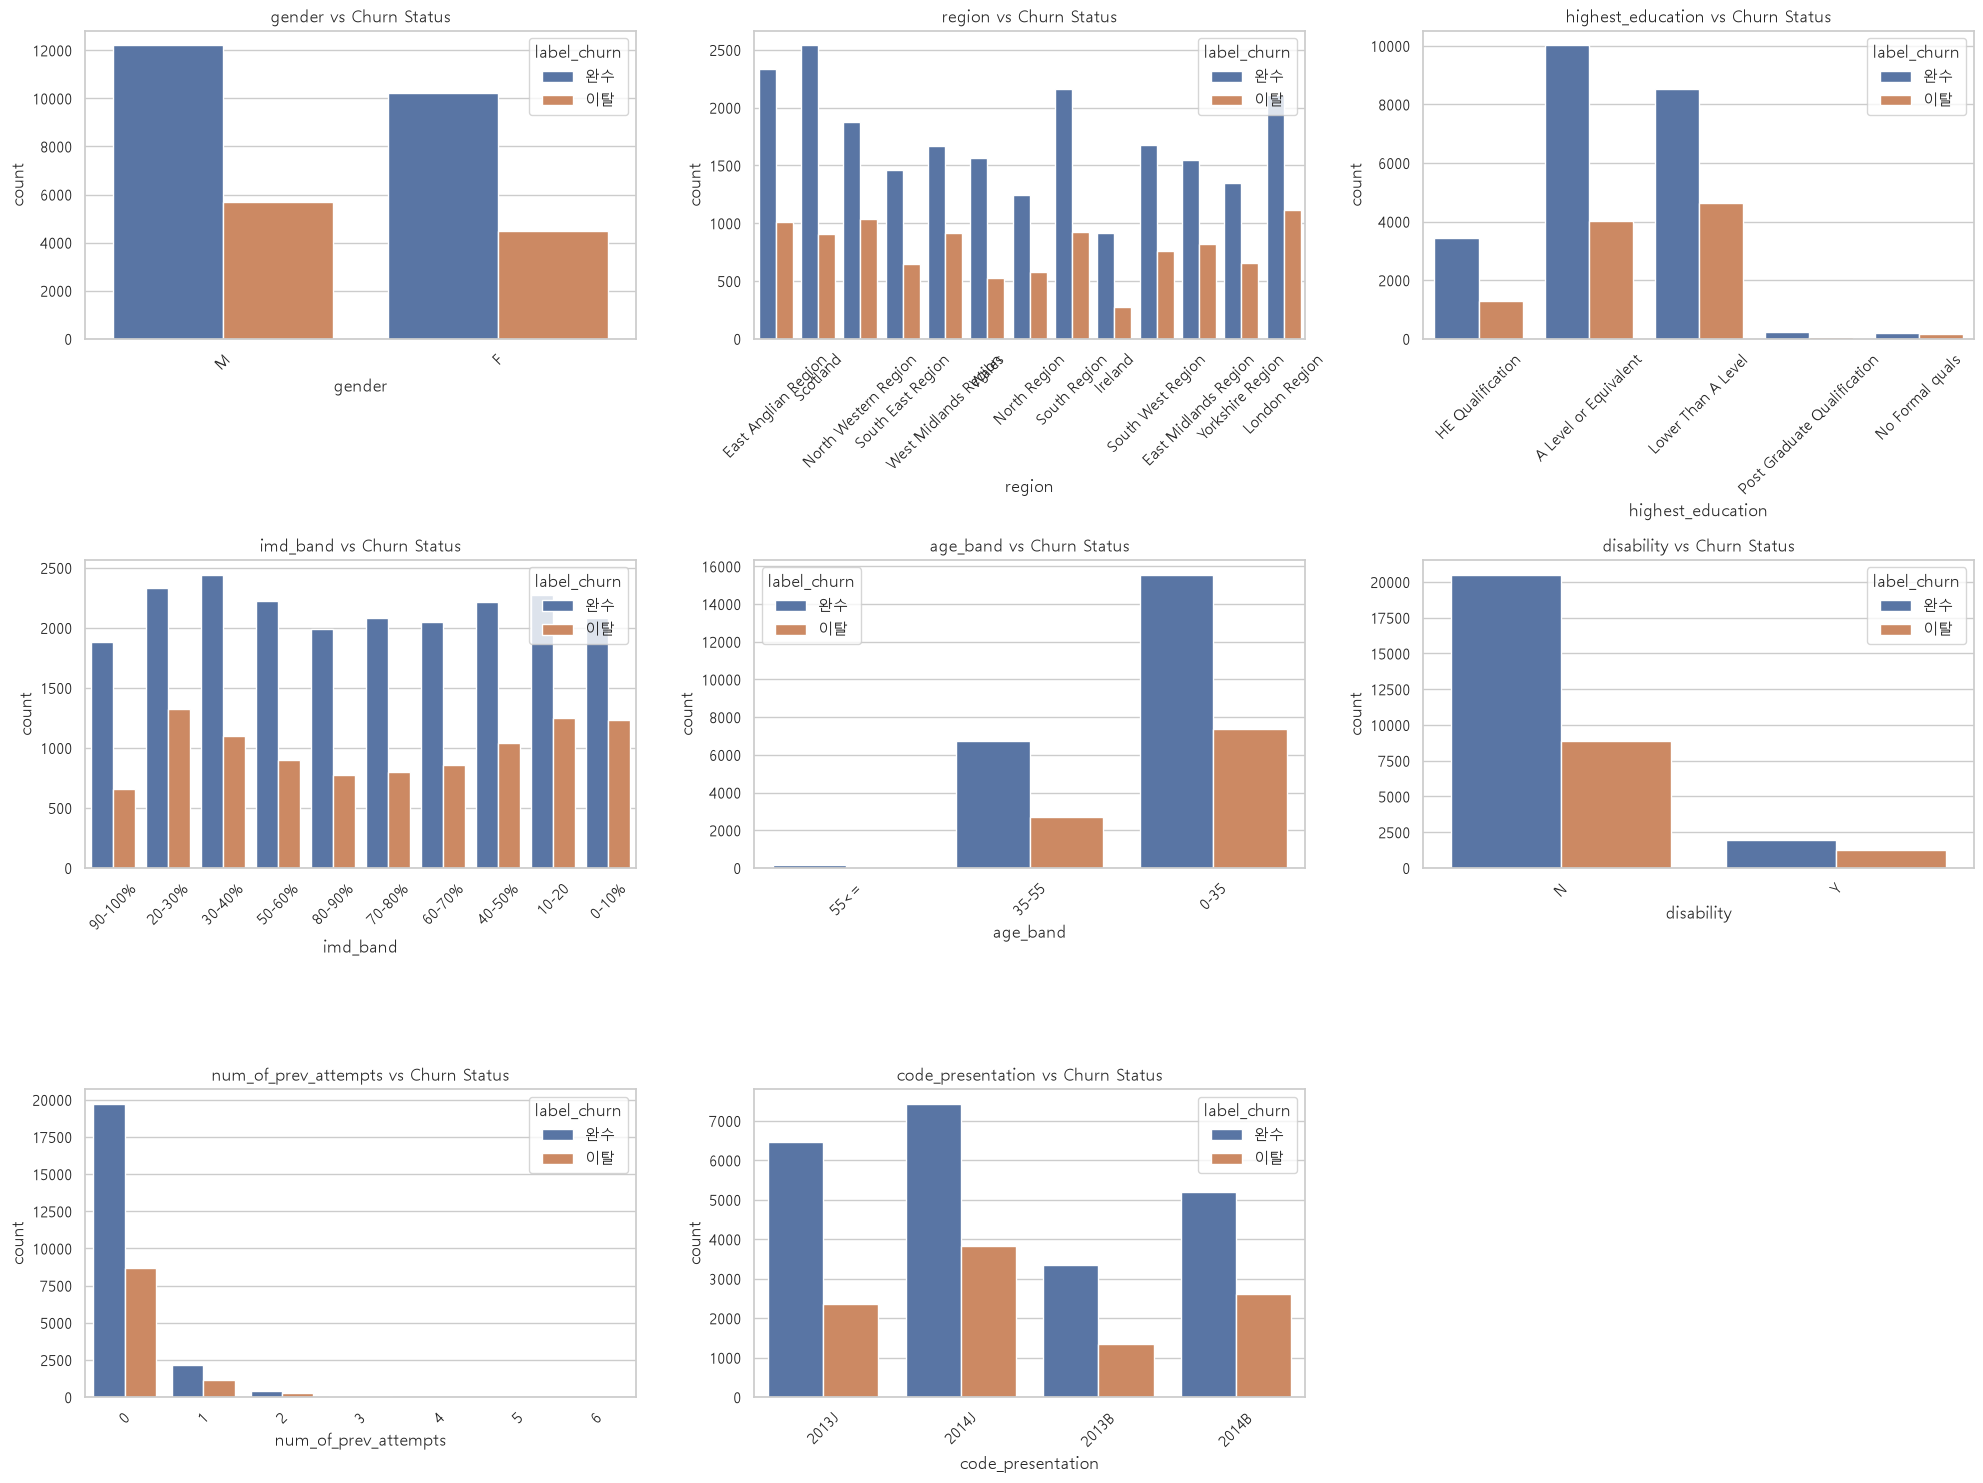

In [33]:
# 1. 시각화할 8개의 속성 리스트 (학생 고유번호와 복잡한 성적 범주는 제외)
cat_cols = ["gender", "region", "highest_education", "imd_band", 
            "age_band", "disability", "num_of_prev_attempts", "code_presentation"]

# 2. 8개의 그래프가 한눈에 들어오도록 전체 도화지 크기(가로 20, 세로 15)를 설정합니다.
plt.figure(figsize=(20, 15))

# 3. 반복문을 사용해서 8개의 속성을 하나씩 꺼내 도화지에 채워 넣습니다.
for i, col in enumerate(cat_cols):
    # 속성이 총 8개이므로, 3행 3열(총 9칸) 도화지로 나누면 딱 한 칸만 남고 예쁘게 찹니다!
    plt.subplot(3, 3, i + 1) 
    
    # hue의 대상을 새로 만든 label_churn으로 변경
    sns.countplot(data=info, x=col, hue="label_churn")
    
    # 그래프 제목과 축 글자가 겹치지 않도록 깔끔하게 다듬어줍니다.
    plt.title(f"{col} vs Churn Status")
    plt.xticks(rotation=45) # 글자가 길어서 겹치지 않게 45도 돌려줍니다.

# 그래프끼리 서로 부딪히지 않게 간격을 자동으로 예쁘게 맞춰줍니다.
plt.tight_layout() 
plt.show()

# [결과] 각 속성별 막대기 안에서 '완수(0)'와 '이탈(1)'이 서로 다른 색으로 나뉘어 출력됩니다.

# 3. 범주형 데이터 분석

"code_module", "code_presentation", "gender", "region", "highest_education", "imd_band", "age_band", "disability"


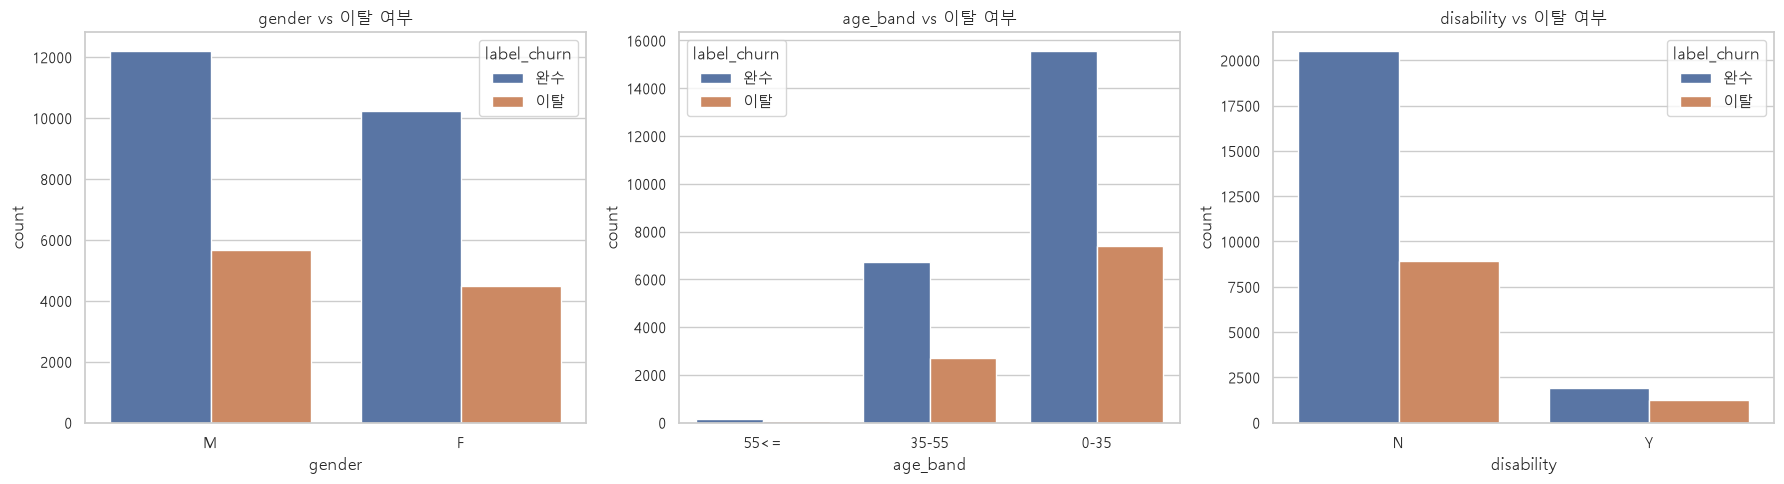

In [34]:
# 성별, 연령대, 장애 여부에 따라 '완수'와 '이탈' 수강생이 각각 몇 명인지 막대그래프로 비교

target_cats = ["gender", "age_band", "disability"]

plt.figure(figsize=(18, 5))

for i, col in enumerate(target_cats):
    plt.subplot(1, 3, i + 1) 
    sns.countplot(data=info, x=col, hue="label_churn")
    plt.title(f"{col} vs 이탈 여부")

# 그래프끼리 서로 어깨를 부딪히지 않도록 간격을 자동으로 정렬해 줍니다.
plt.tight_layout()
plt.show()

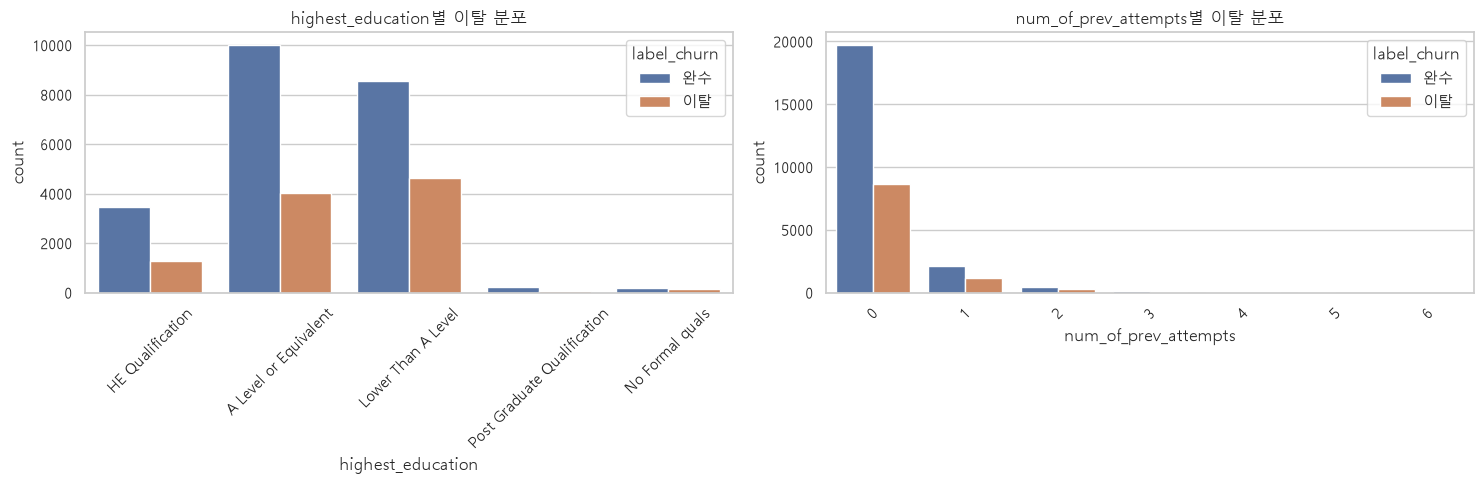

In [36]:
# [한 줄 요약] 교육 수준, 이전 수강 시도 횟수, 수강 학점에 따른 이탈 여부를 확인합니다.
target_cols_2 = ["highest_education", "num_of_prev_attempts"]

plt.figure(figsize=(15, 5))
for i, col in enumerate(target_cols_2):
    plt.subplot(1, 2, i + 1)
    sns.countplot(data=info, x=col, hue="label_churn")
    plt.title(f"{col}별 이탈 분포")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

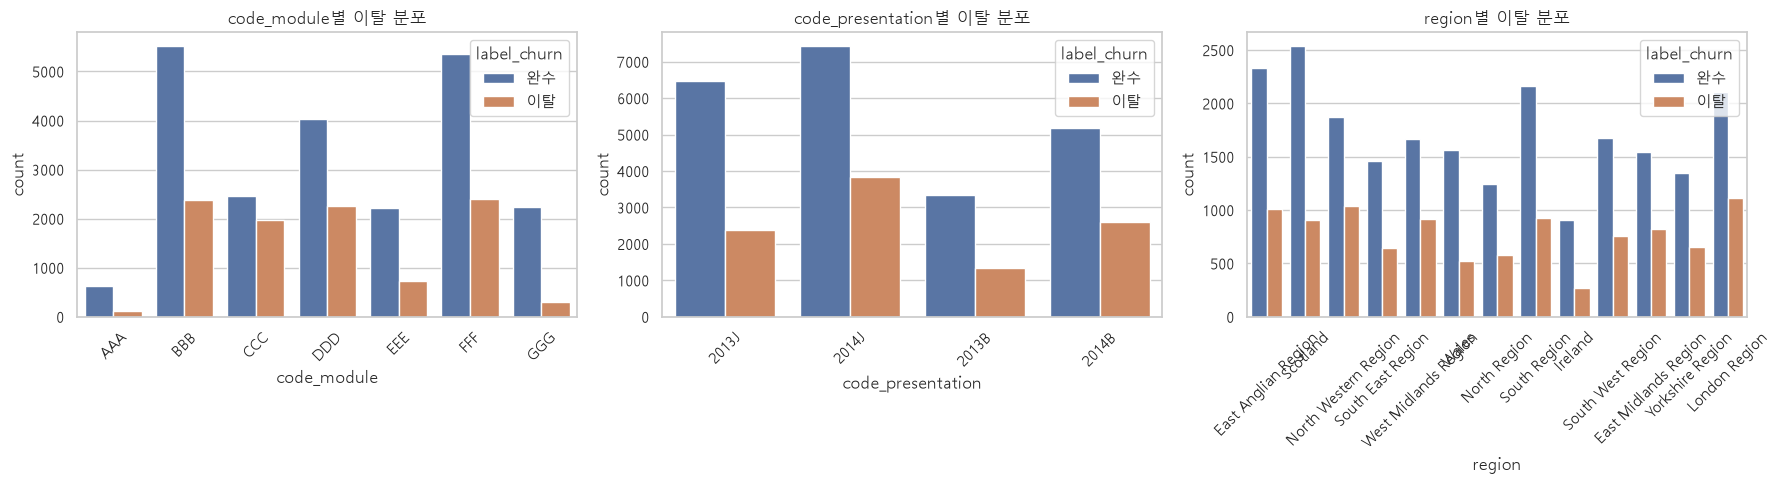

In [38]:
# [한 줄 요약] 어떤 과목(code_module)인지, 어떤 학기(code_presentation)인지에 따른 이탈 분포입니다.
target_cols_3 = ["code_module", "code_presentation", "region"]

plt.figure(figsize=(18, 5))
for i, col in enumerate(target_cols_3):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=info, x=col, hue="label_churn")
    plt.title(f"{col}별 이탈 분포")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3-1. imd_band(빈곤 지수) 데이터 정리 및 시각화

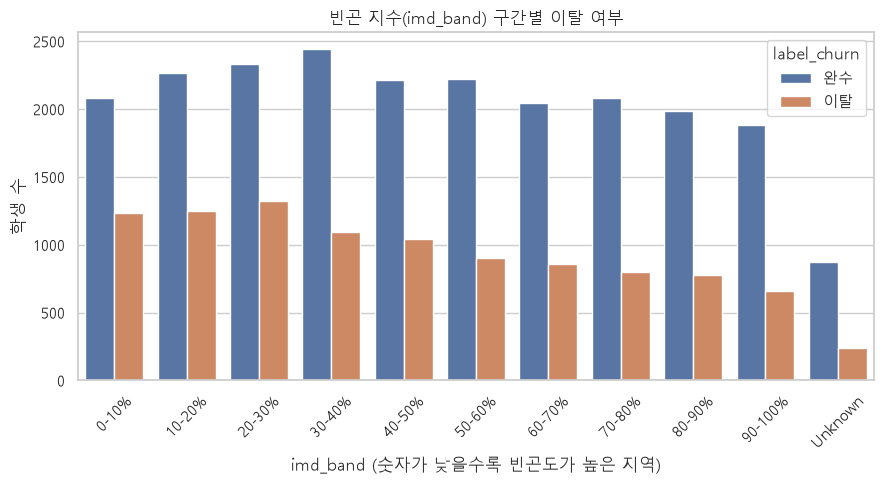

In [39]:
# imd_band는 지역 빈곤 순위(0~100%를 10개 구간으로 나눈 값)입니다.
# 값들을 확인해보면 "10-20"만 다른 구간과 다르게 "%"가 빠져 있어서(오타/원본 데이터 이슈)
# 그래프를 그리기 전에 먼저 표기를 통일해줍니다.
info["imd_band"] = info["imd_band"].replace("10-20", "10-20%")

# imd_band는 결측치(NaN)가 1,111건 있습니다.
# 결측치를 그냥 두면 그래프에서 빠지거나 순서가 뒤죽박죽 되니,
# "Unknown"이라는 별도 카테고리로 만들어서 "얼마나 결측인지"도 같이 보이게 합니다.
info["imd_band"] = info["imd_band"].fillna("Unknown")

# 그래프에서 구간이 0-10% -> 10-20% -> ... 순서대로 보이도록 순서를 직접 지정합니다.
# (그냥 두면 알파벳/등장 순서대로 섞여서 해석하기 어려워집니다)
imd_order = ["0-10%", "10-20%", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%", "Unknown"]

plt.figure(figsize=(9, 5))
sns.countplot(data=info, x="imd_band", hue="label_churn", order=imd_order)
plt.title("빈곤 지수(imd_band) 구간별 이탈 여부")
plt.xlabel("imd_band (숫자가 낮을수록 빈곤도가 높은 지역)")
plt.ylabel("학생 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3-2. 카테고리별 "이탈률(%)" 비교

지금까지 그린 막대그래프는 전부 **인원 수(count)** 기준입니다.
그런데 region이나 code_module처럼 그룹별 학생 수 자체가 크게 다른 변수는,
막대가 높다고 해서 실제로 그 그룹의 이탈 "비율"이 높은 건 아닐 수 있습니다.

그래서 이번엔 그룹별 전체 인원 대비 이탈한 인원의 **비율(%)**만 따로 계산해서 비교합니다.
이렇게 하면 "어떤 그룹이 상대적으로 더 위험한가"를 왜곡 없이 확인할 수 있습니다.

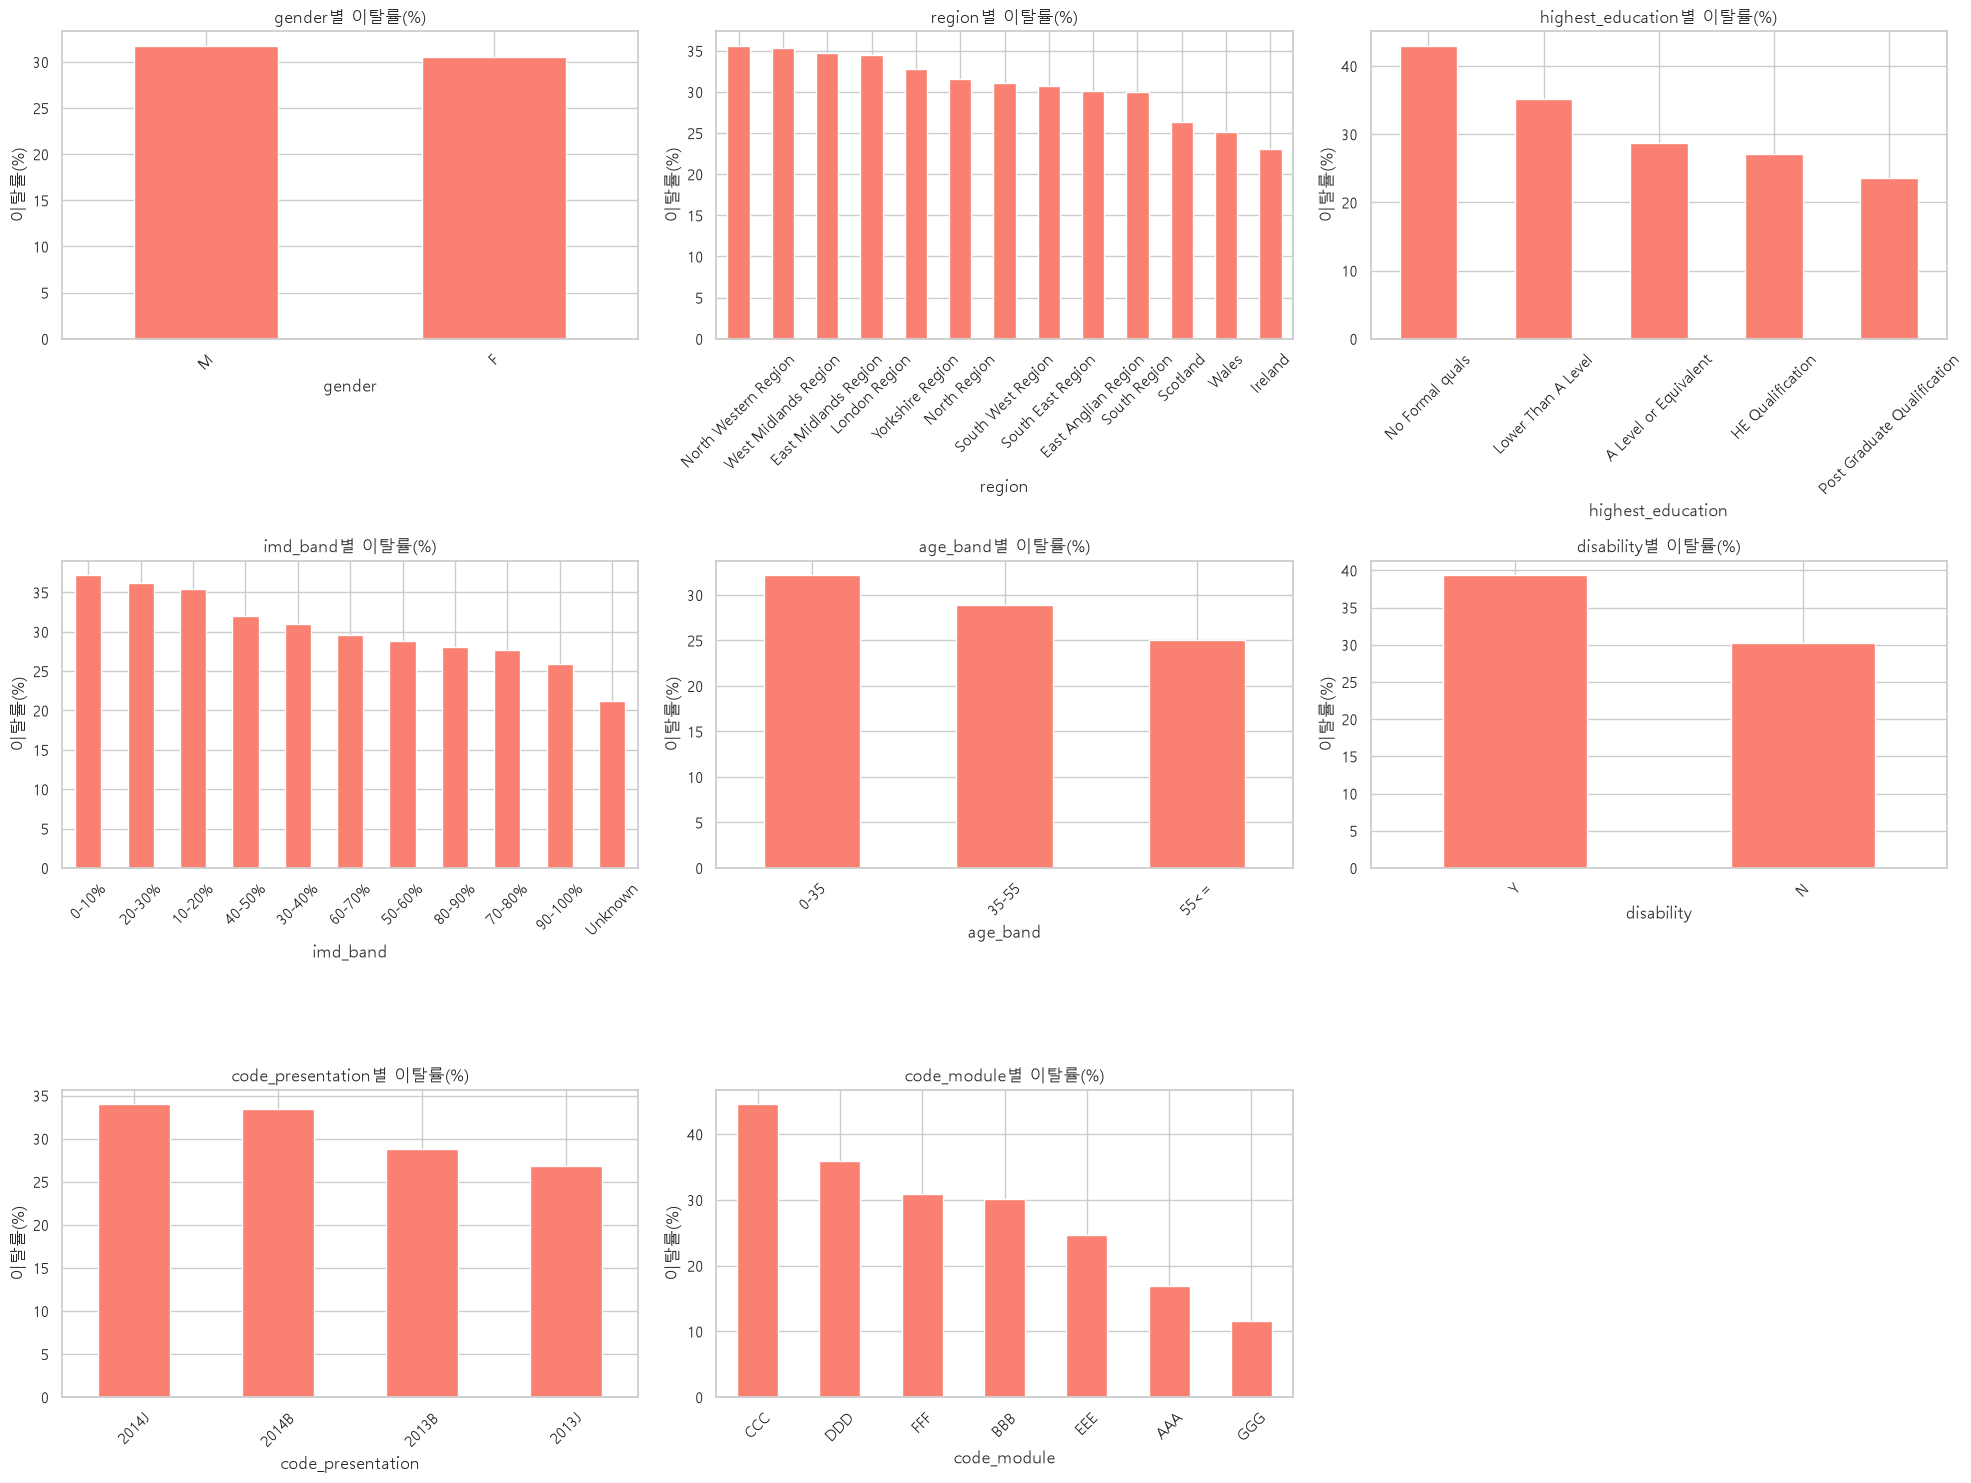

In [40]:
# 이탈률(%) 그래프를 그릴 8개 범주형 변수
cat_cols = ["gender", "region", "highest_education", "imd_band",
            "age_band", "disability", "code_presentation", "code_module"]

plt.figure(figsize=(20, 15))

for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i + 1)

    # groupby(col) : 변수(col)의 각 그룹별로 묶고
    # value_counts(normalize=True) : 그룹 안에서 완수/이탈 비율을 계산 (합쳐서 100%)
    # unstack() : "완수"/"이탈"을 각각 컬럼으로 펼쳐서 표 형태로 만듦
    rate = info.groupby(col)["label_churn"].value_counts(normalize=True).unstack().fillna(0) * 100

    # 이탈률이 높은 그룹부터 순서대로 보이도록 정렬 (한눈에 위험군을 파악하기 위함)
    rate = rate.sort_values("이탈", ascending=False)

    rate["이탈"].plot(kind="bar", color="salmon")
    plt.title(f"{col}별 이탈률(%)")
    plt.ylabel("이탈률(%)")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 3-3. 100% 누적 막대그래프로 완수/이탈 비율 한눈에 보기

위 그래프는 "이탈률"만 따로 보여줬다면, 이번엔 **완수 vs 이탈 비율을 한 막대 안에** 합쳐서
그룹 간 비교가 더 직관적으로 되도록 그립니다. 막대 전체가 항상 100%이기 때문에
그룹별 학생 수가 달라도 공평하게 비교할 수 있습니다.

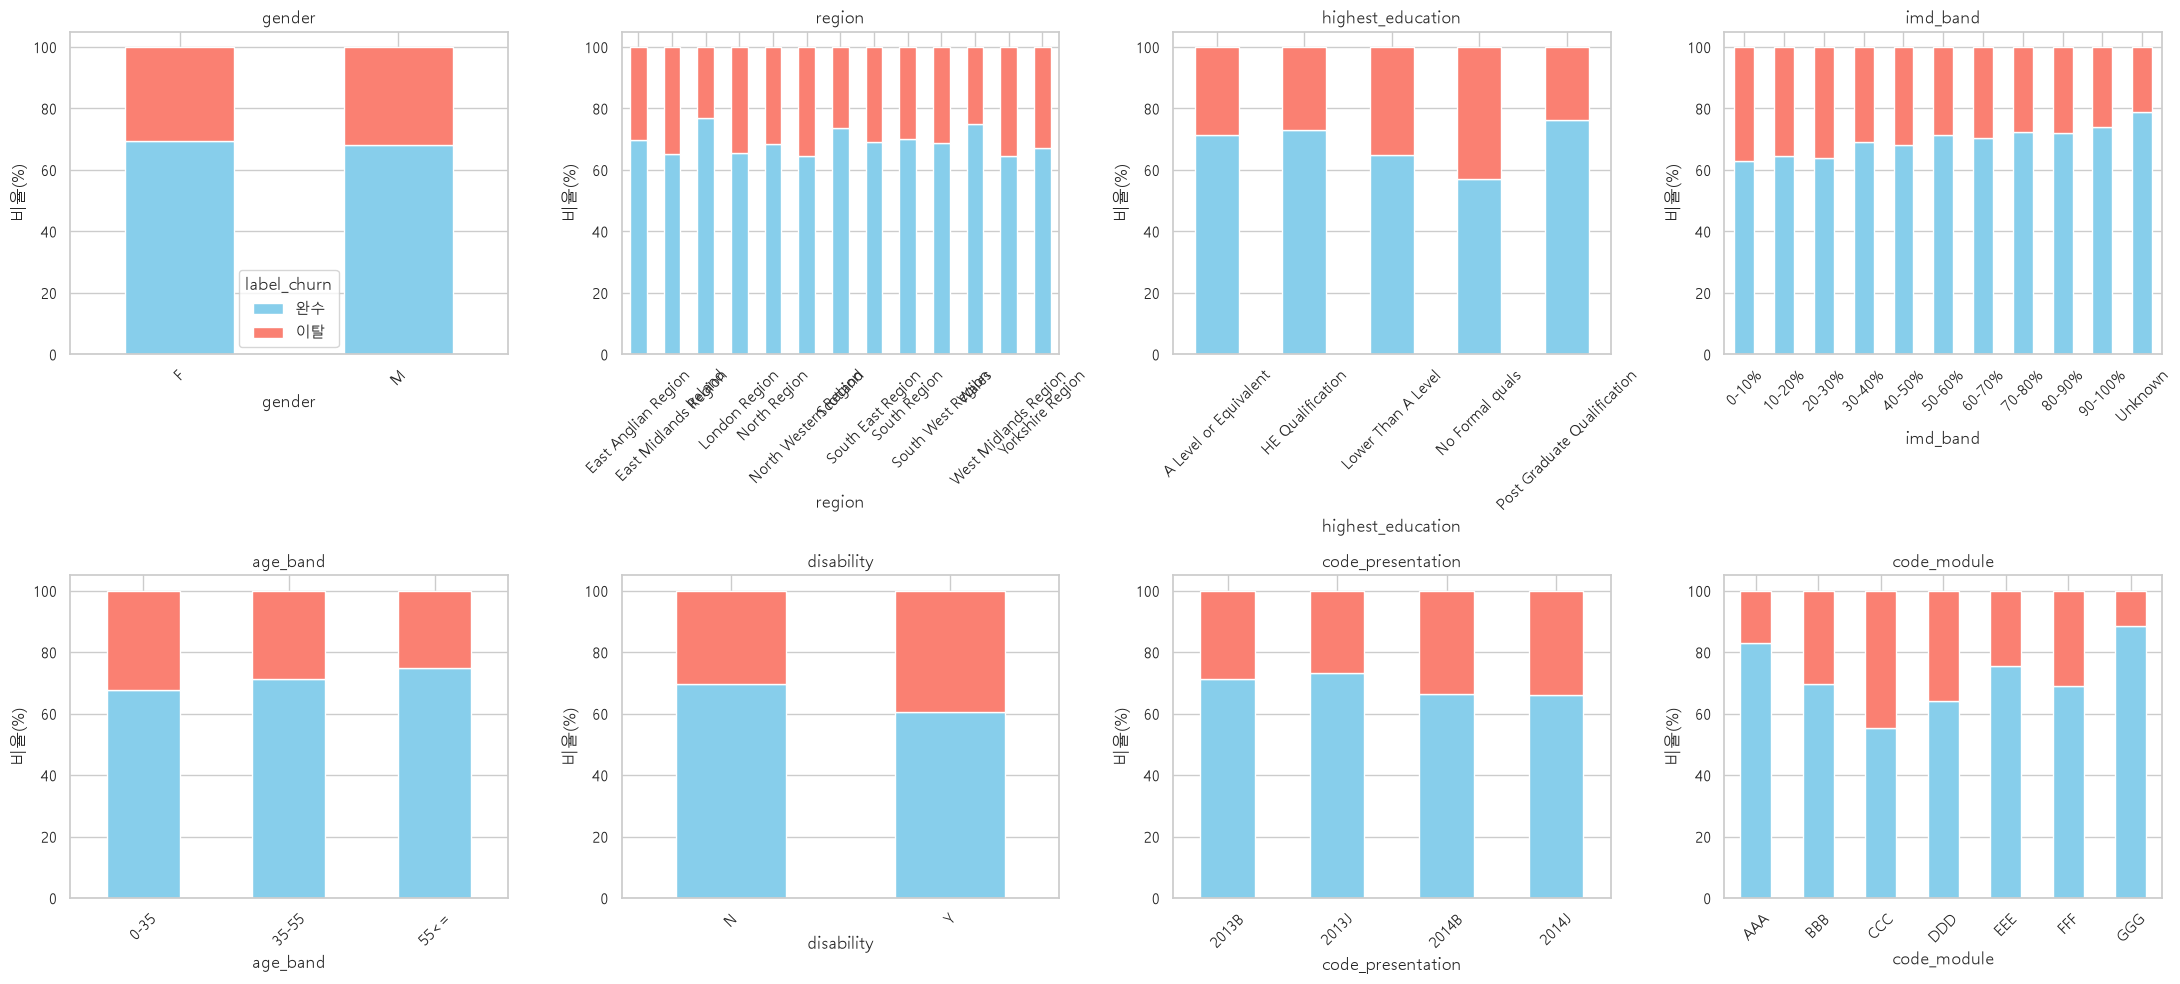

In [41]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = info.groupby(col)["label_churn"].value_counts(normalize=True).unstack().fillna(0) * 100
    # 완수를 아래, 이탈을 위에 쌓는 순서를 고정 (그래프마다 순서가 바뀌면 비교하기 어려움)
    rate = rate[["완수", "이탈"]]

    # stacked=True : 완수 막대 위에 이탈 막대를 쌓아서 전체가 100%가 되도록 표현
    rate.plot(kind="bar", stacked=True, ax=axes[i],
              color=["skyblue", "salmon"], legend=(i == 0))
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("비율(%)")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 3-4. 두 변수를 함께 봤을 때의 이탈률 (교차 히트맵)

한 변수씩 보면 놓치기 쉬운 패턴이 있습니다. 예를 들어 "나이대(age_band)"와
"학력(highest_education)"을 **동시에** 고려했을 때 특정 조합에서만 이탈률이
유독 높을 수도 있습니다. 이런 조합별 위험군을 찾아내면 고용노동부 훈련과정에서
"어떤 특성을 가진 훈련생을 우선 관리해야 하는지" 타겟팅하는 데 바로 활용할 수 있습니다.

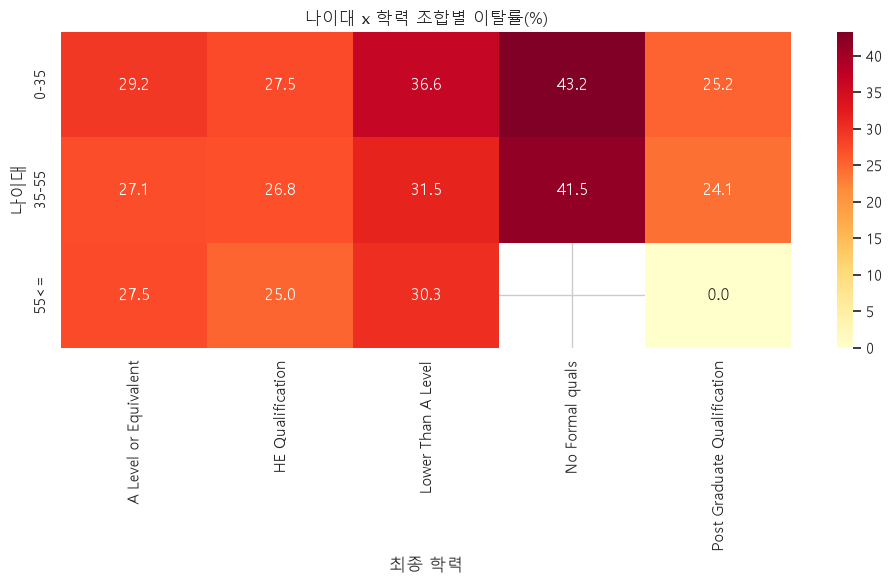

In [42]:
# pd.crosstab에 aggfunc을 넣으면 (행, 열) 조합별로 원하는 계산을 할 수 있습니다.
# 여기서는 각 조합(age_band x highest_education) 안에서 이탈 학생 비율(%)을 계산합니다.
cross = pd.crosstab(
    info["age_band"], info["highest_education"], info["label_churn"],
    aggfunc=lambda x: (x == "이탈").mean() * 100
)

plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("나이대 x 학력 조합별 이탈률(%)")
plt.xlabel("최종 학력")
plt.ylabel("나이대")
plt.tight_layout()
plt.show()

# 참고: 다른 조합(예: region x imd_band)도 위 코드에서 컬럼명만 바꾸면 동일하게 확인 가능합니다.


# 4. 수치형 데이터 분석

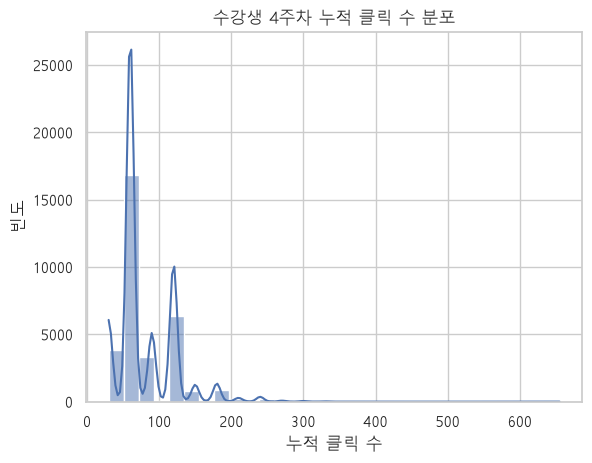

In [35]:
# [한줄 요약] 수강생들의 누적 클릭 수("studied_credits") 분포를 히스토그램으로 확인합니다.
sns.histplot(data=info, x="studied_credits", kde=True, bins=30)
plt.title("수강생 4주차 누적 클릭 수 분포")
plt.xlabel("누적 클릭 수")
plt.ylabel("빈도")
plt.show()

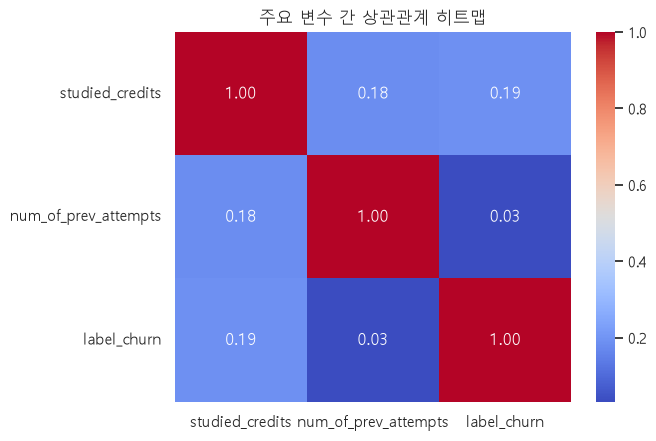

In [44]:
# [한 줄 요약] 수치형 데이터들 사이의 상관관계를 계산하여 히트맵으로 보여줍니다.
# 숫자끼리 얼마나 끈끈하게 연결되어 있는지 확인할 수 있어요!

# 숫자형 변수들만 골라냅니다.
num_cols = ["studied_credits", "num_of_prev_attempts", "label_churn"] 

# 상관관계 계산
corr_df = info[["studied_credits", "num_of_prev_attempts"]].copy()
corr_df["label_churn"] = info["label_churn"].map({"완수": 0, "이탈": 1})
corr = corr_df.corr()

# 히트맵 그리기
sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("주요 변수 간 상관관계 히트맵")
plt.show()

# 5. 이상치 및 그룹별 비교 분석

# 6. 두 변수 간의 관계 분석